In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("D:\ML Projects\ecg-arrhythmia-classifier\mitbih_train.csv" , header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
df.iloc[:,np.r_[0:3,-1]]

,0,1,2,187
0,0.977941,0.926471,0.681373,0.0
1,0.960114,0.863248,0.461538,0.0
2,1.000000,0.659459,0.186486,0.0
3,0.925414,0.665746,0.541436,0.0
4,0.967136,1.000000,0.830986,0.0
...,...,...,...,...
87549,0.807018,0.494737,0.536842,4.0
87550,0.718333,0.605000,0.486667,4.0
87551,0.906122,0.624490,0.595918,4.0
87552,0.858228,0.645570,0.845570,4.0


In [23]:
df.iloc[:, -1].unique()

array([0., 1., 2., 3., 4.])

In [ ]:
df.shape

(87553, 188)

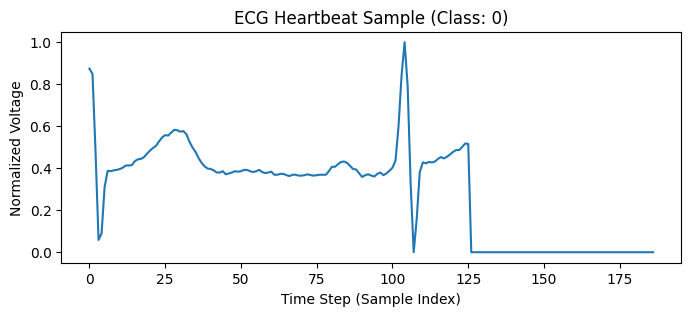

In [26]:


# Separate features (signal) and label
X = df.iloc[:, :187].values   # Shape: (N, 187)
y = df.iloc[:, 187].values    # Shape: (N,)

# Reshape for a 1D-CNN: (batch_size, channels, sequence_length)
# In PyTorch: (N, 1, 187) | In TensorFlow: (N, 187, 1)
X_reshaped = X.reshape(X.shape[0], 1, 187)

# Visualize the first heartbeat
plt.figure(figsize=(8, 3))
plt.plot(X[8])
plt.title(f"ECG Heartbeat Sample (Class: {int(y[8])})")
plt.xlabel("Time Step (Sample Index)")
plt.ylabel("Normalized Voltage")
plt.show()